In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully")


Libraries imported successfully


In [39]:
file_path = "Fashion_Market_Research_250_Real_Sourcedata.xlsx"

df = pd.read_excel(file_path, sheet_name="Product_Data")

print("Data loaded successfully")

Data loaded successfully


In [40]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 366
Columns: 11


,,Brand,Product_Name,Category,Sub_Category,Gender,Selling_Price_INR,Original_Price_INR,Price_Segment,Data_Collected_Date,Source_URL
0,1.0,Nike,Nike Shox TL Men's Shoes,Footwear,Lifestyle,Men,15995,NaN,Luxury/Premium,2026-08-12,https://www.nike.in/
1,2.0,Nike,Nike Zoom Vomero 5 Men's Shoes,Footwear,Lifestyle,Men,14995,NaN,Luxury/Premium,2026-08-12,https://www.nike.in/
2,3.0,Nike,Nike Air Max 95 Older Bubble Men's Shoes,Footwear,Lifestyle,Men,16995,NaN,Luxury/Premium,2026-08-12,https://www.nike.in/
3,4.0,Nike,Nike Ava X Mesh Men's Shoes,Footwear,Lifestyle,Men,10795,NaN,Luxury/Premium,2026-08-12,https://www.nike.in/
4,5.0,Nike,Nike Air Max Dn8 Men's Shoes,Footwear,Lifestyle,Men,17495,NaN,Luxury/Premium,2026-08-12,https://www.nike.in/


In [41]:
print(df.columns.tolist())

[' ', 'Brand', 'Product_Name', 'Category', 'Sub_Category', 'Gender', 'Selling_Price_INR', 'Original_Price_INR', 'Price_Segment', 'Data_Collected_Date', 'Source_URL']


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0                        242 non-null    float64
 1   Brand                242 non-null    object 
 2   Product_Name         242 non-null    object 
 3   Category             242 non-null    object 
 4   Sub_Category         296 non-null    object 
 5   Gender               247 non-null    object 
 6   Selling_Price_INR    194 non-null    object 
 7   Original_Price_INR   38 non-null     float64
 8   Price_Segment        189 non-null    object 
 9   Data_Collected_Date  242 non-null    object 
 10  Source_URL           242 non-null    object 
dtypes: float64(2), object(9)
memory usage: 31.6+ KB


In [43]:
df.describe()

,,Original_Price_INR
count,242.000000,38.000000
mean,121.500000,2824.894737
std,70.003571,2650.095172
min,1.000000,799.000000
25%,61.250000,1621.750000
50%,121.500000,2149.000000
75%,181.750000,2990.000000
max,242.000000,16995.000000


In [44]:
missing_values = df.isnull().sum()

print(missing_values)


                       124
Brand                  124
Product_Name           124
Category               124
Sub_Category            70
Gender                 119
Selling_Price_INR      172
Original_Price_INR     328
Price_Segment          177
Data_Collected_Date    124
Source_URL             124
dtype: int64


In [45]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing_Values": missing_values,
    "Missing_Percentage": missing_percentage.round(2)
})

missing_summary

,Missing_Values,Missing_Percentage
,124,33.88
Brand,124,33.88
Product_Name,124,33.88
Category,124,33.88
Sub_Category,70,19.13
Gender,119,32.51
Selling_Price_INR,172,46.99
Original_Price_INR,328,89.62
Price_Segment,177,48.36
Data_Collected_Date,124,33.88


In [16]:
print("N/A values:")
print((df == "N/A").sum())

N/A values:
                       0
Brand                  0
Product_Name           0
Category               0
Sub_Category           0
Gender                 0
Selling_Price_INR      0
Original_Price_INR     0
Price_Segment          0
Data_Collected_Date    0
Source_URL             0
dtype: int64


In [17]:
# Keep only the 242 actual product records
df_clean = df.iloc[:242].copy()

print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])

Rows: 242
Columns: 11


In [18]:
df_clean.rename(columns={' ': 'Record_ID'}, inplace=True)

print(df_clean.columns.tolist())

['Record_ID', 'Brand', 'Product_Name', 'Category', 'Sub_Category', 'Gender', 'Selling_Price_INR', 'Original_Price_INR', 'Price_Segment', 'Data_Collected_Date', 'Source_URL']


In [19]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242 entries, 0 to 241
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Record_ID            242 non-null    float64
 1   Brand                242 non-null    object 
 2   Product_Name         242 non-null    object 
 3   Category             242 non-null    object 
 4   Sub_Category         242 non-null    object 
 5   Gender               242 non-null    object 
 6   Selling_Price_INR    189 non-null    object 
 7   Original_Price_INR   38 non-null     float64
 8   Price_Segment        189 non-null    object 
 9   Data_Collected_Date  242 non-null    object 
 10  Source_URL           242 non-null    object 
dtypes: float64(2), object(9)
memory usage: 20.9+ KB


In [20]:
missing_summary = pd.DataFrame({
    'Missing_Values': df_clean.isnull().sum(),
    'Missing_Percentage': (df_clean.isnull().sum() / len(df_clean) * 100).round(2)
})

missing_summary

,Missing_Values,Missing_Percentage
Record_ID,0,0.0
Brand,0,0.0
Product_Name,0,0.0
Category,0,0.0
Sub_Category,0,0.0
Gender,0,0.0
Selling_Price_INR,53,21.9
Original_Price_INR,204,84.3
Price_Segment,53,21.9
Data_Collected_Date,0,0.0


In [21]:
na_summary = (df_clean == 'N/A').sum()

print(na_summary)

Record_ID              0
Brand                  0
Product_Name           0
Category               0
Sub_Category           0
Gender                 0
Selling_Price_INR      0
Original_Price_INR     0
Price_Segment          0
Data_Collected_Date    0
Source_URL             0
dtype: int64


In [22]:
# Check duplicate rows
duplicate_count = df_clean.duplicated().sum()

print("Duplicate records:", duplicate_count)

Duplicate records: 0


In [23]:
print("Brands:")
print(df_clean['Brand'].value_counts())

print("\nCategories:")
print(df_clean['Category'].value_counts())

print("\nGender:")
print(df_clean['Gender'].value_counts())

print("\nPrice Segment:")
print(df_clean['Price_Segment'].value_counts())

Brands:
Brand
Nike      50
Zara      50
UNIQLO    49
adidas    47
H&M       46
Name: count, dtype: int64

Categories:
Category
Apparel        147
Footwear        82
Innerwear        8
Accessories      2
Sportswear       1
Home             1
Beauty           1
Name: count, dtype: int64

Gender:
Gender
Women          153
Men             49
Unspecified     34
Kids             3
Unisex           3
Name: count, dtype: int64

Price Segment:
Price_Segment
Budget            66
Mid-range         62
Premium           32
Luxury/Premium    29
Name: count, dtype: int64


In [24]:
print("Top 20 Sub-Categories:")
print(df_clean['Sub_Category'].value_counts().head(20))

Top 20 Sub-Categories:
Sub_Category
Dress         48
Lifestyle     31
Running       16
Originals     15
T-Shirt       15
Pants         12
Top            9
Shirt          8
Sportswear     6
Basketball     5
Cricket        5
Trousers       4
Jumpsuit       4
Shorts         4
Jeans          3
Leggings       3
Jacket         3
Football       3
Slides         3
Bra            3
Name: count, dtype: int64


In [25]:
# Convert Selling Price to numeric
df_clean['Selling_Price_INR'] = pd.to_numeric(
    df_clean['Selling_Price_INR'], errors='coerce'
)

# Brand-wise pricing analysis
brand_analysis = df_clean.groupby('Brand').agg(
    Total_Products=('Product_Name', 'count'),
    Available_Prices=('Selling_Price_INR', 'count'),
    Average_Price=('Selling_Price_INR', 'mean'),
    Minimum_Price=('Selling_Price_INR', 'min'),
    Maximum_Price=('Selling_Price_INR', 'max')
).round(2)

brand_analysis

,Total_Products,Available_Prices,Average_Price,Minimum_Price,Maximum_Price
Brand,,,,,
H&M,46,25,1226.20,399.0,2499.0
Nike,50,42,10483.67,1295.0,17495.0
UNIQLO,49,49,2032.86,490.0,5990.0
Zara,50,48,4310.42,750.0,8550.0
adidas,47,25,7325.00,599.0,19999.0


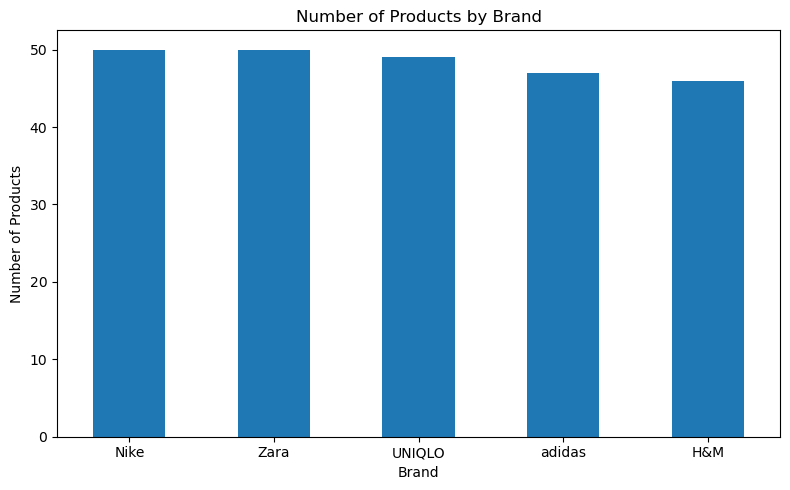

In [26]:
plt.figure(figsize=(8,5))

brand_counts = df_clean['Brand'].value_counts()

brand_counts.plot(kind='bar')

plt.title('Number of Products by Brand')
plt.xlabel('Brand')
plt.ylabel('Number of Products')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

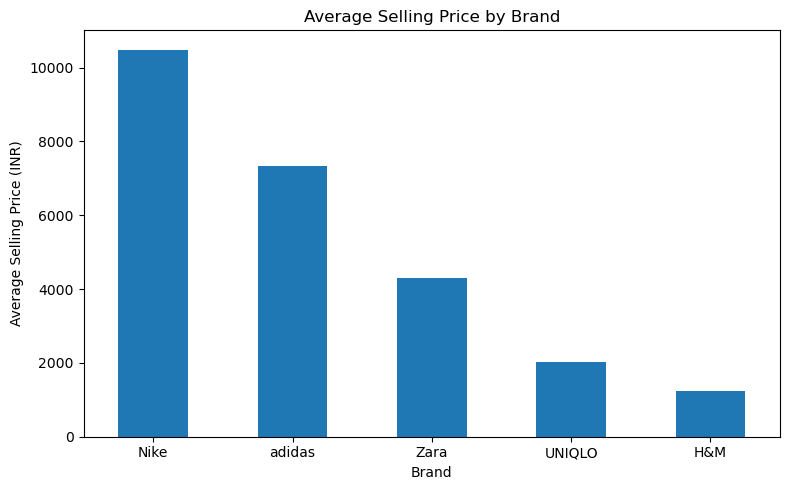

In [27]:
plt.figure(figsize=(8,5))

brand_analysis['Average_Price'].sort_values(ascending=False).plot(kind='bar')

plt.title('Average Selling Price by Brand')
plt.xlabel('Brand')
plt.ylabel('Average Selling Price (INR)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [28]:
brand_analysis = df_clean.groupby('Brand').agg(
    Total_Products=('Product_Name', 'count'),
    Available_Prices=('Selling_Price_INR', 'count'),
    Average_Price=('Selling_Price_INR', 'mean'),
    Minimum_Price=('Selling_Price_INR', 'min'),
    Maximum_Price=('Selling_Price_INR', 'max')
).round(2)

brand_analysis

,Total_Products,Available_Prices,Average_Price,Minimum_Price,Maximum_Price
Brand,,,,,
H&M,46,25,1226.20,399.0,2499.0
Nike,50,42,10483.67,1295.0,17495.0
UNIQLO,49,49,2032.86,490.0,5990.0
Zara,50,48,4310.42,750.0,8550.0
adidas,47,25,7325.00,599.0,19999.0


In [29]:
df_clean = df.iloc[:242].copy()

In [30]:
df_clean.to_csv("Week3_Clean_Product_Data.csv", index=False)

In [31]:
import os

print(os.path.exists("Week3_Clean_Product_Data.csv"))

True


In [32]:
clean_check = pd.read_csv("Week3_Clean_Product_Data.csv")

print("Rows:", clean_check.shape[0])
print("Columns:", clean_check.shape[1])

clean_check.head()

Rows: 242
Columns: 11


,,Brand,Product_Name,Category,Sub_Category,Gender,Selling_Price_INR,Original_Price_INR,Price_Segment,Data_Collected_Date,Source_URL
0,1.0,Nike,Nike Shox TL Men's Shoes,Footwear,Lifestyle,Men,15995.0,NaN,Luxury/Premium,2026-08-12,https://www.nike.in/
1,2.0,Nike,Nike Zoom Vomero 5 Men's Shoes,Footwear,Lifestyle,Men,14995.0,NaN,Luxury/Premium,2026-08-12,https://www.nike.in/
2,3.0,Nike,Nike Air Max 95 Older Bubble Men's Shoes,Footwear,Lifestyle,Men,16995.0,NaN,Luxury/Premium,2026-08-12,https://www.nike.in/
3,4.0,Nike,Nike Ava X Mesh Men's Shoes,Footwear,Lifestyle,Men,10795.0,NaN,Luxury/Premium,2026-08-12,https://www.nike.in/
4,5.0,Nike,Nike Air Max Dn8 Men's Shoes,Footwear,Lifestyle,Men,17495.0,NaN,Luxury/Premium,2026-08-12,https://www.nike.in/


In [33]:
print(df_clean.shape)

(242, 11)


In [34]:
import os

print(os.path.abspath("Week3_Clean_Product_Data.csv"))

C:\Users\patil hiral\Hiral\Week3_Clean_Product_Data.csv


In [48]:
df_clean.columns = [
    'Record_ID',
    'Brand',
    'Product_Name',
    'Category',
    'Sub_Category',
    'Gender',
    'Selling_Price_INR',
    'Original_Price_INR',
    'Price_Segment',
    'Data_Collected_Date',
    'Source_URL'
]

df_clean.to_csv("Week3_Clean_Product_Data.csv", index=False)

print("CSV updated successfully")
print(df_clean.columns.tolist())

CSV updated successfully
['Record_ID', 'Brand', 'Product_Name', 'Category', 'Sub_Category', 'Gender', 'Selling_Price_INR', 'Original_Price_INR', 'Price_Segment', 'Data_Collected_Date', 'Source_URL']


In [49]:
print(df_clean.columns.tolist())

['Record_ID', 'Brand', 'Product_Name', 'Category', 'Sub_Category', 'Gender', 'Selling_Price_INR', 'Original_Price_INR', 'Price_Segment', 'Data_Collected_Date', 'Source_URL']


In [50]:
df_clean.to_csv("Week3_Clean_Product_Data_Final.csv", index=False)

print("Saved successfully")

Saved successfully


In [51]:
import os

print(os.path.abspath("Week3_Clean_Product_Data.csv"))

C:\Users\patil hiral\Hiral\Week3_Clean_Product_Data.csv
